<a href="https://colab.research.google.com/github/changsksu/IMSE_Data_Science/blob/main/ARMA(1_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

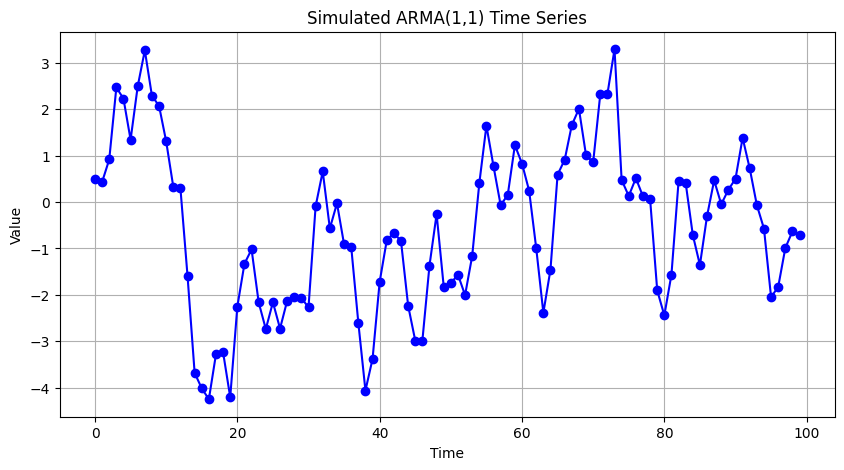

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess

# 1. Define the parameters
# Note: statsmodels uses the form: y(t) - phi*y(t-1) = e(t) + theta*e(t-1)
# So we provide the coefficients with signs for the LHS and RHS
ar_coeffs = np.array([1, -0.75])  # AR(1) phi = 0.75
ma_coeffs = np.array([1, 0.4])    # MA(1) theta = 0.4

# 2. Initialize the ARMA process
arma_process = ArmaProcess(ar_coeffs, ma_coeffs)

# 3. Simulate 100 observations
np.random.seed(42) # For reproducibility
simulated_data = arma_process.generate_sample(nsample=100)

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(simulated_data, marker='o', linestyle='-', color='b')
plt.title('Simulated ARMA(1,1) Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.show()

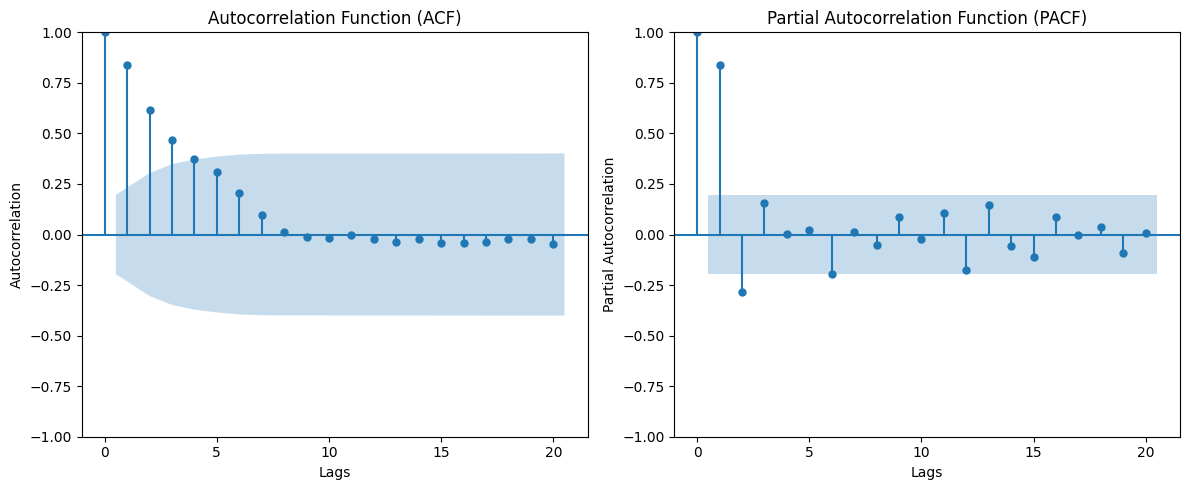

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF
plt.figure(figsize=(12, 5))
plot_acf(simulated_data, lags=20, ax=plt.subplot(121))
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')

# Plot PACF
plot_pacf(simulated_data, lags=20, ax=plt.subplot(122))
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

The **Autocorrelation Function (ACF)** measures the correlation between a time series and a lagged version of itself. It helps identify the moving average (MA) order of an ARMA model. In an ARMA(1,1) process, the ACF will typically show a decaying pattern.

The **Partial Autocorrelation Function (PACF)** measures the correlation between a time series and a lagged version of itself, after accounting for the correlations at intermediate lags. It helps identify the autoregressive (AR) order of an ARMA model. For an ARMA(1,1) process, the PACF will also typically show a decaying pattern, but with a significant spike at lag 1 for both AR and MA components.